In [1]:
%pip install pyserial matplotlib

   ---------------------------------------- 0.0/90.6 kB ? eta -:--:--
   ------------------------------------ --- 81.9/90.6 kB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 90.6/90.6 kB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
import csv, os, time
from datetime import datetime
import serial
import numpy as np
import matplotlib.pyplot as plt

PORT = "COM11"                    # your ESP32's port
CSV_FILE = "kynetix_weights_run2.csv"  # every recording gets added to this one file
COLS = ["timestamp", "weight_g", "t_s", "ticks", "delta_ticks", "cap_pF", "delta_pF", "timeouts"]

try:
    ser.close()   # if this cell is re-run, close the old connection first
except NameError:
    pass
ser = serial.Serial(PORT, 115200, timeout=0.1)
print("Connected. Waiting for the ESP32 baseline - don't touch the sensor...")
time.sleep(3)
ser.reset_input_buffer()
print("Ready.")

def _parse(line):
    parts = line.strip().split(",")
    if len(parts) != 6 or parts[1] == "TIMEOUT":
        return None
    try:
        return [float(p) for p in parts]
    except ValueError:
        return None   # header or text line

def rezero():
    """Nothing on the sensor! Takes a new baseline."""
    ser.reset_input_buffer()
    ser.write(b"b\n")
    end = time.time() + 3
    while time.time() < end:
        line = ser.readline().decode(errors="ignore")
        if line.startswith(("Baseline", "ERROR", "WARNING")):
            print(line.strip())

def record(weight_g, seconds=10, settle=2):
    """Put the weight on FIRST, then run this. Adds the readings to CSV_FILE."""
    ser.reset_input_buffer()
    time.sleep(settle)            # let the reading settle
    ser.reset_input_buffer()
    rows, t0 = [], time.time()
    while time.time() - t0 < seconds:
        r = _parse(ser.readline().decode(errors="ignore"))
        if r:
            rows.append(r)
    if not rows:
        print("No readings - check the port, CSV_MODE = true on the ESP32, and the wiring.")
        return
    new_file = not os.path.exists(CSV_FILE)
    stamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(CSV_FILE, "a", newline="") as f:
        w = csv.writer(f)
        if new_file:
            w.writerow(COLS)
        for t, ticks, dticks, cap, dpf, tmo in rows:
            w.writerow([stamp, weight_g, t, ticks, dticks, cap, dpf, int(tmo)])
    d = np.array([r[4] for r in rows])
    print(f"{weight_g} g: {len(rows)} readings, change = {d.mean():+.4f} pF (spread ±{d.std():.4f})")
    plt.figure(figsize=(8, 2.5))
    plt.plot(np.array([r[0] for r in rows]) - rows[0][0], d)
    plt.xlabel("Time (s)"); plt.ylabel("Change (pF)"); plt.title(f"{weight_g} g")
    plt.grid(alpha=0.3); plt.show()

Connected. Waiting for the ESP32 baseline - don't touch the sensor...
Ready.


Baseline: 1955.7 ticks = 5.86 pF (0 of 500 timed out)


In [7]:
rezero()

Baseline: 1939.8 ticks = 5.81 pF (0 of 500 timed out)


0 g: 1001 readings, change = -0.0135 pF (spread ±0.0117)


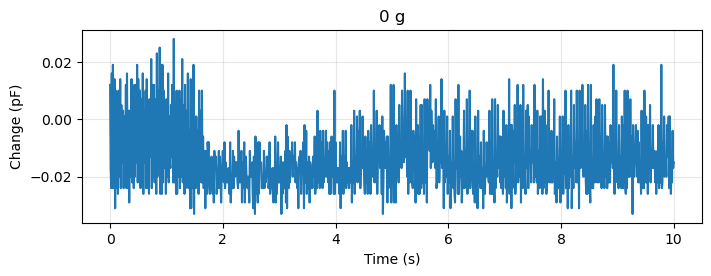

In [9]:
record(0)


100 g: 1001 readings, change = +0.1108 pF (spread ±0.0062)


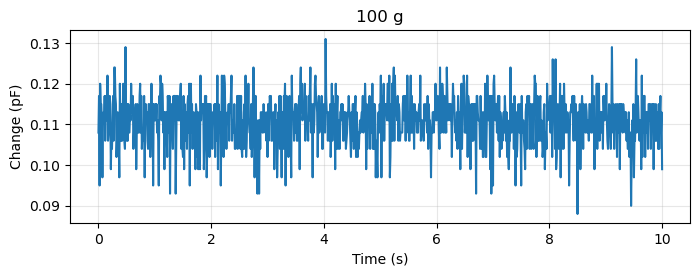

In [11]:
record(100)

200 g: 1002 readings, change = +0.1272 pF (spread ±0.0083)


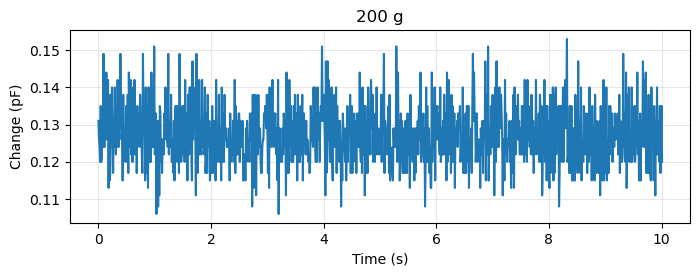

In [13]:
record(200)

300 g: 1001 readings, change = +0.1543 pF (spread ±0.0123)


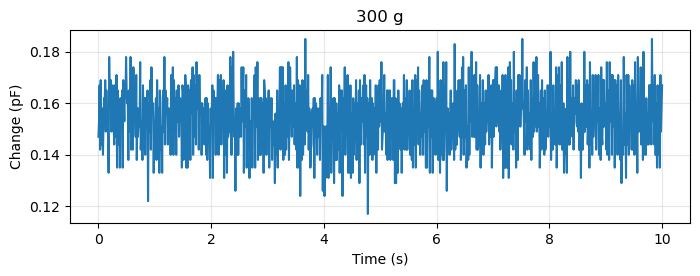

In [15]:
record(300)

400 g: 1001 readings, change = +0.1761 pF (spread ±0.0086)


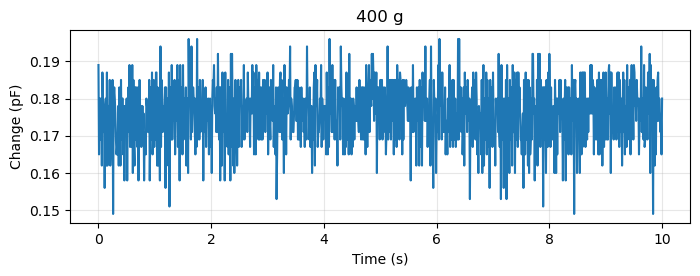

In [17]:
record(400)

500 g: 1001 readings, change = +0.1859 pF (spread ±0.0053)


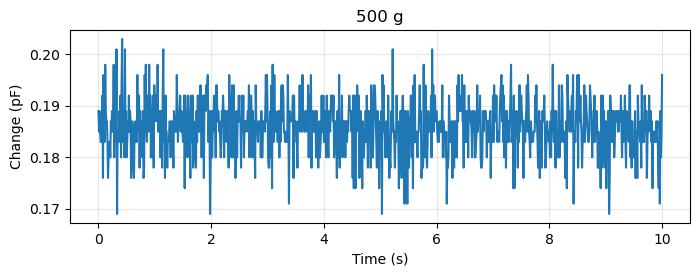

In [19]:
record(500)

600 g: 1001 readings, change = +0.1898 pF (spread ±0.0052)


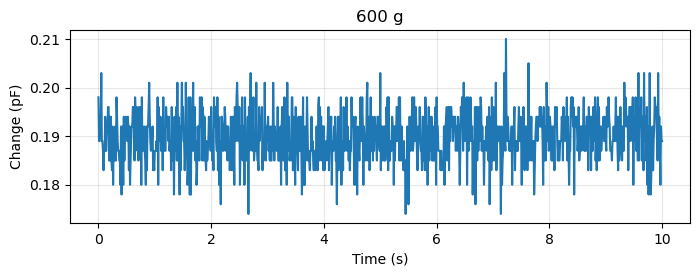

In [21]:
record(600)

700 g: 1002 readings, change = +0.1919 pF (spread ±0.0061)


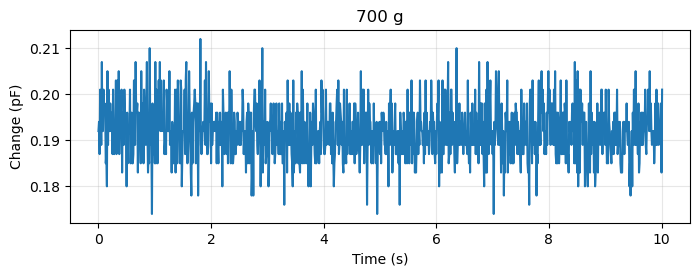

In [23]:
record(700)

800 g: 1001 readings, change = +0.2012 pF (spread ±0.0094)


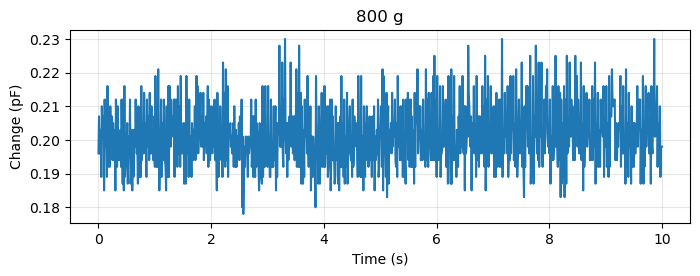

In [25]:
record(800)

900 g: 1001 readings, change = +0.2083 pF (spread ±0.0111)


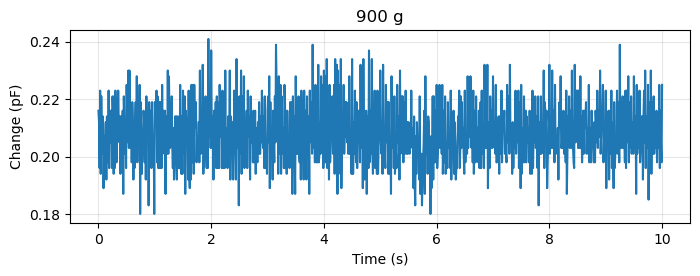

In [27]:
record(900)

       0 g   -0.0135 pF   ±0.0117
     100 g   +0.1108 pF   ±0.0062
     200 g   +0.1272 pF   ±0.0083
     300 g   +0.1543 pF   ±0.0123
     400 g   +0.1761 pF   ±0.0086
     500 g   +0.1859 pF   ±0.0053
     600 g   +0.1898 pF   ±0.0052
     700 g   +0.1919 pF   ±0.0061
     800 g   +0.2012 pF   ±0.0094
     900 g   +0.2083 pF   ±0.0111


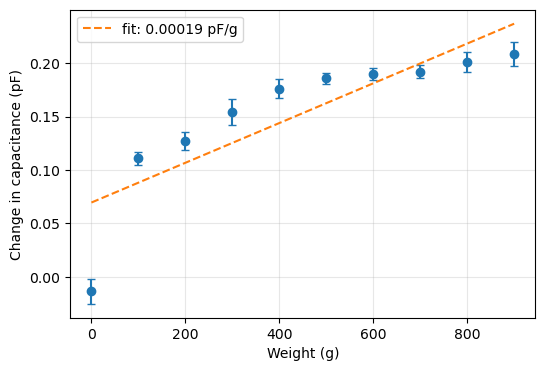

In [29]:
data = {}
with open(CSV_FILE) as f:
    for row in csv.DictReader(f):
        data.setdefault(float(row["weight_g"]), []).append(float(row["delta_pF"]))
w = np.array(sorted(data))
m = np.array([np.mean(data[k]) for k in w])
s = np.array([np.std(data[k]) for k in w])
for wi, mi, si in zip(w, m, s):
    print(f"{wi:8.0f} g   {mi:+.4f} pF   ±{si:.4f}")
plt.figure(figsize=(6, 4))
plt.errorbar(w, m, yerr=s, fmt="o", capsize=3)
if len(w) >= 2:
    slope, icpt = np.polyfit(w, m, 1)
    plt.plot(w, slope * w + icpt, "--", label=f"fit: {slope:.5f} pF/g")
    plt.legend()
plt.xlabel("Weight (g)"); plt.ylabel("Change in capacitance (pF)"); plt.grid(alpha=0.3)
plt.savefig("kynetix_calibration.png", dpi=150); plt.show()

In [29]:
ser.close()

In [ ]:
print(os.path.abspath(CSV_FILE))
os.startfile(os.path.abspath(CSV_FILE))

C:\Users\catel\kynetix_weights.csv


In [ ]:
CSV_FILE = "kynetix_weights_run2.csv"
rezero()

In [ ]:
rezero()